In [2]:
# Carga de librerias
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings(action='ignore')
import matplotlib.pyplot
import os

In [23]:
os.chdir('C:\\Users\\USUARIO\\Desktop\\Trabajo\\Iberoamericana\\Cursos\\Electiva ciencia de datos para decisiones\\Metodos descriptivos')

In [24]:
os.listdir()

['Ejemplo_regresion.ipynb',
 'Employees.csv',
 'Employee_target.csv',
 'Métodos descriptivos (código) (2).zip',
 'Métodos descriptivos de ciencia de datos para la toma de decisiones (notebook).ipynb',
 'Métodos descriptivos de ciencia de datos para la toma de decisiones (notebook).pdf',
 'solicitud_creditos_info.csv']

In [25]:
df = pd.read_csv('solicitud_creditos_info.csv')

In [26]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251617 entries, 0 to 251616
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   index                     251617 non-null  int64  
 1   default                   251617 non-null  int64  
 2   contract_type             251617 non-null  object 
 3   gender                    251617 non-null  object 
 4   flag_vehicle              251617 non-null  object 
 5   flag_properties           251617 non-null  object 
 6   num_children              251617 non-null  int64  
 7   total_income              251617 non-null  float64
 8   loan_amount               251617 non-null  float64
 9   income_type               251617 non-null  object 
 10  marital_status            251617 non-null  object 
 11  age                       251617 non-null  float64
 12  work_age                  251617 non-null  float64
 13  flag_cellphone            251617 non-null  i

,index,default,contract_type,gender,flag_vehicle,flag_properties,num_children,total_income,loan_amount,income_type,...,num_petic_bureau_day,num_petic_bureau_week,num_petic_bureau_month,num_petic_bureau_quarter,num_petic_bureau_year,block_month,year,month,Office,Employee
0,0,1,personal loan,M,N,Y,0,394338.0,1207961.0,shareholder,...,0.0,0.0,2.0,0.0,4.0,10,2017,10,110143,38
1,1,1,personal loan,F,N,Y,0,322796.0,409690.0,salary,...,0.0,0.0,0.0,0.0,1.0,4,2017,4,110143,38
2,2,1,personal loan,M,N,Y,1,241201.0,858450.0,salary,...,0.0,0.0,0.0,0.0,1.0,10,2017,10,110143,38
3,3,1,personal loan,M,N,N,1,264255.0,114679.0,salary,...,0.0,0.0,0.0,0.0,1.0,2,2017,2,110143,35
4,4,1,personal loan,F,N,Y,1,166682.0,402669.0,salary,...,0.0,0.0,0.0,0.0,1.0,12,2017,12,110143,38


In [27]:
# Columna con el mes en formato fecha
df['fecha'] = df['year'].astype(str) + '/' + df['month'].astype(str) + '/28'
df['fecha'] = pd.to_datetime(df['fecha'])

In [28]:
# Un KPI relevante podria ser el valor total de los créditos gestionados por los empleados
df_KPI_gestores = pd.pivot_table(df, index = ['Employee'], columns = 'fecha', values='loan_amount')
df_KPI_gestores

fecha,2017-01-28,2017-02-28,2017-03-28,2017-04-28,2017-05-28,2017-06-28,2017-07-28,2017-08-28,2017-09-28,2017-10-28,...,2019-03-28,2019-04-28,2019-05-28,2019-06-28,2019-07-28,2019-08-28,2019-09-28,2019-10-28,2019-11-28,2019-12-28
Employee,,,,,,,,,,,,,,,,,,,,,
10,595664.593458,611621.826733,609579.018692,624584.651584,6.005471e+05,622979.313636,557215.199029,609953.047393,608803.921951,646188.500000,...,729447.029661,719781.772532,742334.827957,728729.371429,663484.046392,785580.643216,652479.728205,7.385362e+05,677772.908676,642128.352381
11,616516.946237,558917.829268,556918.623188,624253.301075,6.591237e+05,614228.750000,561639.756098,565832.172414,569532.012195,608984.431818,...,636021.242424,667066.230769,727710.682927,597743.945946,571660.357143,702418.044776,554024.256098,6.952246e+05,631338.324324,794260.728571
13,528948.875000,603366.750000,487860.142857,925867.000000,1.210880e+06,439543.800000,540525.000000,576670.666667,657555.000000,548430.111111,...,483984.333333,792846.833333,561886.400000,410571.250000,623772.285714,536148.250000,816257.750000,9.705906e+05,871518.000000,746001.800000
14,635398.447368,635305.459016,629447.023256,585854.853846,5.760347e+05,598824.392982,561882.387352,602983.770161,568711.050980,601404.832827,...,701152.622302,687273.696113,684395.376518,674279.229323,632715.231405,678975.175439,682778.822394,7.179087e+05,654277.337037,644972.363971
16,540301.595238,590528.297297,714558.340909,534016.512195,6.648776e+05,620800.900000,597180.975610,571449.333333,637167.292683,511699.913043,...,639249.478261,754223.102564,593322.833333,558739.685714,618782.846154,820029.233333,559862.102564,5.076685e+05,861551.108696,683059.945946
17,633279.655172,586315.984848,612920.555556,630667.544118,6.551614e+05,553301.057143,689892.431034,592619.703125,530178.796875,661667.855263,...,682866.971831,725361.521739,657496.507937,593345.015152,541308.933333,627846.131579,620990.178571,6.223611e+05,699780.619718,740937.173077
18,614031.141509,642970.169903,601096.071770,592316.521368,6.306913e+05,608390.399103,629165.375000,547407.346734,626449.050420,613667.656827,...,665458.175299,658825.115556,655621.524510,678312.018519,771600.320225,705057.384236,714173.065990,7.738042e+05,706267.387560,765607.363636
27,657609.736842,562051.507692,512916.178571,685697.087719,5.243179e+05,518594.781818,627193.673913,621438.288462,602080.872727,523657.242857,...,640463.972222,787298.089552,626189.175439,697175.383333,663072.524590,826930.739130,590418.960784,7.659407e+05,622213.196078,675921.285714
29,600197.946136,624650.158854,610371.918919,603980.031315,5.930711e+05,573959.484848,613191.075829,587158.988532,600082.786667,611029.654618,...,676398.112311,686750.748538,639816.911227,656615.770408,659455.097633,672380.713542,695157.410390,7.029558e+05,629239.220430,679800.941645


In [29]:
# Top 3 empleados con menor performance
df_KPI_gestores.sort_values('20191228').head(3)

fecha,2017-01-28,2017-02-28,2017-03-28,2017-04-28,2017-05-28,2017-06-28,2017-07-28,2017-08-28,2017-09-28,2017-10-28,...,2019-03-28,2019-04-28,2019-05-28,2019-06-28,2019-07-28,2019-08-28,2019-09-28,2019-10-28,2019-11-28,2019-12-28
Employee,,,,,,,,,,,,,,,,,,,,,
33,506681.666667,465210.666667,913463.800000,639798.500000,761186.600000,364328.000000,723631.750000,411324.285714,522281.000000,874250.285714,...,622499.000000,493694.200000,523726.00000,499448.600000,497531.200000,379536.333333,441779.500000,1.035937e+06,NaN,314712.500000
45,489459.500000,873091.500000,673089.193548,671608.880000,563494.275862,761903.724138,415186.714286,603436.238095,857287.380952,697389.136364,...,732441.166667,687072.100000,906591.00000,727244.173913,669031.000000,650828.636364,633314.304348,6.208708e+05,744091.730769,609516.720000
87,642870.727273,591801.950920,643067.938111,620173.246499,630102.077882,617967.783862,590174.922840,609859.782178,586027.944984,609002.642045,...,692063.657609,692727.364407,617886.66967,636757.028571,718197.867133,659623.957447,731288.709559,6.656033e+05,700992.342466,625416.427083


In [30]:
# Top 3 empleados con mejor performance
df_KPI_gestores.sort_values('20191228').tail(3)

fecha,2017-01-28,2017-02-28,2017-03-28,2017-04-28,2017-05-28,2017-06-28,2017-07-28,2017-08-28,2017-09-28,2017-10-28,...,2019-03-28,2019-04-28,2019-05-28,2019-06-28,2019-07-28,2019-08-28,2019-09-28,2019-10-28,2019-11-28,2019-12-28
Employee,,,,,,,,,,,,,,,,,,,,,
79,533572.528571,550382.895833,593800.660377,604063.913043,599278.546667,554999.071429,642109.630769,498225.433962,511464.231884,676518.350000,...,702803.154762,636328.130435,627059.803922,748317.684932,703845.631579,614649.306122,688097.300000,772560.442308,656059.022222,832382.083333
37,544542.190476,505881.235294,459635.074074,717842.250000,672021.695652,470034.000000,584357.281250,526192.000000,581156.666667,612488.791667,...,650218.880000,616036.923077,720735.333333,583400.740741,598491.344828,664189.882353,886256.896552,710209.320000,619439.136364,867154.782609
69,534113.651163,647428.391304,655432.100000,534009.604167,510002.440000,645750.813953,581456.478261,600149.411765,674122.895833,687855.380952,...,516677.090909,745336.587302,755020.075472,699402.525000,696291.156250,766677.636364,768253.500000,767221.657895,548465.525000,877270.684211


<Axes: xlabel='fecha'>

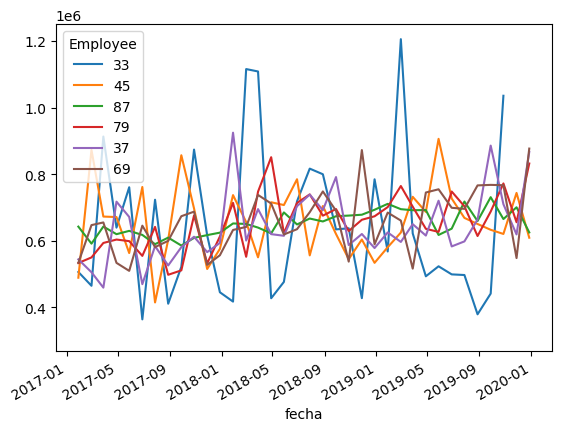

In [31]:
# Grafiquemos
pd.concat([df_KPI_gestores.sort_values('20191228').head(3), df_KPI_gestores.sort_values('20191228').tail(3)]).T.plot()

In [32]:
# Creación de la variable de productividad de los empleados ﴾en este caso número de crédit
# Se pueden crear otras variables de productividad ﴾valor de los créditos, evolución de l﴿
df_target_e = df.query("year==2019").groupby('Employee').count()['index'].to_frame().reset_index()
df_target_e.rename({'index':'Productividad'}, inplace=True, axis=1) # Renombrar la column
df_target_e.head()

,Employee,Productividad
0,10,2491
1,11,991
2,13,78
3,14,3110
4,16,468


In [54]:
df_employees = pd.read_csv("Employees.csv")
df_employees.info()
df_employees.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee              32 non-null     int64  
 1   employee_age          32 non-null     int64  
 2   employe_gender        32 non-null     object 
 3   exp_previa            32 non-null     int64  
 4   employee_estudios     32 non-null     object 
 5   resul_prub_seleccion  32 non-null     float64
 6   eval_jefeRH           32 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.9+ KB


,Employee,employee_age,employe_gender,exp_previa,employee_estudios,resul_prub_seleccion,eval_jefeRH
0,10,38,F,10,Secud. Completa,8.6,8.4
1,11,35,M,4,Técnico,8.4,8.7
2,13,24,M,1,Uni. Completo,9.2,9.1
3,14,44,F,12,Secud. Completa,8.1,8.9
4,16,32,M,1,Uni. Completo,8.3,8.4


In [58]:
df_target_e = pd.merge(df_target_e, df_employees, on = 'Employee') 
df_target_e.head()

,Employee,Productividad,employee_age_x,exp_previa_x,employee_estudios_x,resul_prub_seleccion_x,eval_jefeRH_x,Constante,gender_F,gender_M,...,exp_previa_y,employee_estudios_y,resul_prub_seleccion_y,eval_jefeRH_y,employee_age,employe_gender_y,exp_previa,employee_estudios,resul_prub_seleccion,eval_jefeRH
0,10,2491,38,10,Secud. Completa,8.6,8.4,1,True,False,...,10,Secud. Completa,8.6,8.4,38,F,10,Secud. Completa,8.6,8.4
1,11,991,35,4,Técnico,8.4,8.7,1,False,True,...,4,Técnico,8.4,8.7,35,M,4,Técnico,8.4,8.7
2,13,78,24,1,Uni. Completo,9.2,9.1,1,False,True,...,1,Uni. Completo,9.2,9.1,24,M,1,Uni. Completo,9.2,9.1
3,14,3110,44,12,Secud. Completa,8.1,8.9,1,True,False,...,12,Secud. Completa,8.1,8.9,44,F,12,Secud. Completa,8.1,8.9
4,16,468,32,1,Uni. Completo,8.3,8.4,1,False,True,...,1,Uni. Completo,8.3,8.4,32,M,1,Uni. Completo,8.3,8.4


In [14]:
# Exporto estos datos ﴾pueden ser utiles despues﴿
df_target_e.to_csv('Employee_target.csv', index=False)

In [56]:
# Librerias para modelos estadísticos
import statsmodels.api as sm

In [57]:
df_target_e.head()

,Employee,Productividad,employee_age_x,exp_previa_x,employee_estudios_x,resul_prub_seleccion_x,eval_jefeRH_x,Constante,gender_F,gender_M,employee_age_y,employe_gender,exp_previa_y,employee_estudios_y,resul_prub_seleccion_y,eval_jefeRH_y
0,10,2491,38,10,Secud. Completa,8.6,8.4,1,True,False,38,F,10,Secud. Completa,8.6,8.4
1,11,991,35,4,Técnico,8.4,8.7,1,False,True,35,M,4,Técnico,8.4,8.7
2,13,78,24,1,Uni. Completo,9.2,9.1,1,False,True,24,M,1,Uni. Completo,9.2,9.1
3,14,3110,44,12,Secud. Completa,8.1,8.9,1,True,False,44,F,12,Secud. Completa,8.1,8.9
4,16,468,32,1,Uni. Completo,8.3,8.4,1,False,True,32,M,1,Uni. Completo,8.3,8.4


In [37]:
df_target_e['Constante'] = 1

In [38]:
df_target_e.head()

,Employee,Productividad,employee_age,employe_gender,exp_previa,employee_estudios,resul_prub_seleccion,eval_jefeRH,Constante
0,10,2491,38,F,10,Secud. Completa,8.6,8.4,1
1,11,991,35,M,4,Técnico,8.4,8.7,1
2,13,78,24,M,1,Uni. Completo,9.2,9.1,1
3,14,3110,44,F,12,Secud. Completa,8.1,8.9,1
4,16,468,32,M,1,Uni. Completo,8.3,8.4,1


In [39]:
x1 = df_target_e[['Constante','exp_previa']] #Matriz

In [40]:
x1.head(10)

,Constante,exp_previa
0,1,10
1,1,4
2,1,1
3,1,12
4,1,1
5,1,1
6,1,12
7,1,3
8,1,8
9,1,13


In [41]:
m1 = sm.OLS(df_target_e['Productividad'],x1) #Especificación del modelo (Y,X)
m1 = m1.fit() #Ajuste del modelo
print(m1.summary())


                            OLS Regression Results                            
Dep. Variable:          Productividad   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     136.5
Date:                Mon, 02 Oct 2023   Prob (F-statistic):           1.09e-12
Time:                        18:49:39   Log-Likelihood:                -267.35
No. Observations:                  32   AIC:                             538.7
Df Residuals:                      30   BIC:                             541.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Constante   -336.0940    311.125     -1.080      0.2

In [20]:
df_target_e.head()

,Employee,Productividad,employee_age,employe_gender,exp_previa,employee_estudios,resul_prub_seleccion,eval_jefeRH,Constante
0,10,2491,38,F,10,Secud. Completa,8.6,8.4,1
1,11,991,35,M,4,Técnico,8.4,8.7,1
2,13,78,24,M,1,Uni. Completo,9.2,9.1,1
3,14,3110,44,F,12,Secud. Completa,8.1,8.9,1
4,16,468,32,M,1,Uni. Completo,8.3,8.4,1


In [21]:
df_target_e.columns

Index(['Employee', 'Productividad', 'employee_age', 'employe_gender',
       'exp_previa', 'employee_estudios', 'resul_prub_seleccion',
       'eval_jefeRH', 'Constante'],
      dtype='object')

In [43]:
#Numéricas
x2 = df_target_e[['Employee','employee_age','exp_previa','resul_prub_seleccion','eval_jefeRH','Constante']]

In [44]:
x2.head()

,Employee,employee_age,exp_previa,resul_prub_seleccion,eval_jefeRH,Constante
0,10,38,10,8.6,8.4,1
1,11,35,4,8.4,8.7,1
2,13,24,1,9.2,9.1,1
3,14,44,12,8.1,8.9,1
4,16,32,1,8.3,8.4,1


In [45]:
m2 = sm.OLS(df_target_e['Productividad'], x2) # Especificar el modelo
m2 = m2.fit() # Ajustar el modelo
print(m2.summary()) # Resulmen del modelo en pantalla

                            OLS Regression Results                            
Dep. Variable:          Productividad   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     26.95
Date:                Mon, 02 Oct 2023   Prob (F-statistic):           1.64e-09
Time:                        18:59:25   Log-Likelihood:                -265.62
No. Observations:                  32   AIC:                             543.2
Df Residuals:                      26   BIC:                             552.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Employee                 9.1191 

In [46]:
y = np.log(df_target_e['Productividad']) # Variable objetivo en el objeto y es el logaritmo

In [47]:
m3 = sm.OLS(y, x2) # Especificar el modelo
m3 = m3.fit() # Ajustar el modelo
print(m3.summary()) # Resulmen del modelo en pantalla


                            OLS Regression Results                            
Dep. Variable:          Productividad   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     16.58
Date:                Mon, 02 Oct 2023   Prob (F-statistic):           2.27e-07
Time:                        19:02:26   Log-Likelihood:                -30.008
No. Observations:                  32   AIC:                             72.02
Df Residuals:                      26   BIC:                             80.81
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Employee                 0.0035 

In [27]:
df_target_e.columns

Index(['Employee', 'Productividad', 'employee_age', 'employe_gender',
       'exp_previa', 'employee_estudios', 'resul_prub_seleccion',
       'eval_jefeRH', 'Constante'],
      dtype='object')

In [48]:
df_target_e = pd.get_dummies(df_target_e, columns=['employe_gender'], prefix='gender')

In [49]:
df_target_e.head()

,Employee,Productividad,employee_age,exp_previa,employee_estudios,resul_prub_seleccion,eval_jefeRH,Constante,gender_F,gender_M
0,10,2491,38,10,Secud. Completa,8.6,8.4,1,True,False
1,11,991,35,4,Técnico,8.4,8.7,1,False,True
2,13,78,24,1,Uni. Completo,9.2,9.1,1,False,True
3,14,3110,44,12,Secud. Completa,8.1,8.9,1,True,False
4,16,468,32,1,Uni. Completo,8.3,8.4,1,False,True


In [52]:
me = sm.OLS(y, df_target_e['gender_F']) # Especificar el modelo
me = me.fit() # Ajustar el modelo
print(me.summary()) # Resulmen del modelo en pantalla

                                 OLS Regression Results                                
Dep. Variable:          Productividad   R-squared (uncentered):                   0.639
Model:                            OLS   Adj. R-squared (uncentered):              0.628
Method:                 Least Squares   F-statistic:                              54.99
Date:                Mon, 02 Oct 2023   Prob (F-statistic):                    2.37e-08
Time:                        19:10:27   Log-Likelihood:                         -93.049
No. Observations:                  32   AIC:                                      188.1
Df Residuals:                      31   BIC:                                      189.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [53]:
df_target_e['gender_dummy'] = df_target_e['employe_gender'].map({'M': 1, 'F': 0})


KeyError: 'employe_gender'

In [12]:
ejemplo = np.array([2.5,2.6,3,2.2,10])

In [13]:
ejemplo.mean(), np.median(ejemplo) #Medidas de centralida; outliers.

(4.0600000000000005, 2.6)

In [16]:
np.var(ejemplo) # ingresos al cuadrado
np.std(ejemplo)

2.9810065414218734

In [20]:
# Coefiente de correlación
100 *np.std(ejemplo) / ejemplo.mean()  # DANE: CV = 15%

73.42380643896239